# Import libaries

In [27]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 0. Load data

In [28]:
# Download latest version
path = kagglehub.dataset_download(
    "vjchoudhary7/customer-segmentation-tutorial-in-python",
    output_dir="data"
)

DATA_DIR = Path("data")
DATA_FILE = DATA_DIR / "Mall_Customers.csv"

print(f"Dataset: {DATA_FILE}")

Dataset: data\Mall_Customers.csv


# 1. Data inspection
- shape
- basic information about rows and columns
- null values
- duplicates

In [29]:
df = pd.read_csv(DATA_FILE)

print("=" * 50)
print("DATA INSPECTION")
print("=" * 50)

# Dataset shape
print(f"\nDataset shape: {df.shape[0]} rows × {df.shape[1]} columns")

# Column information
print("\n" + "-" * 50)
print("COLUMN INFORMATION")
print("-" * 50)

df.info()

# Missing values
print("\n" + "-" * 50)
print("MISSING VALUES")
print("-" * 50)

missing_values = df.isnull().sum()

if missing_values.sum() == 0:
    print("No missing values found.")
else:
    print(missing_values[missing_values > 0])

# Duplicates
print("\n" + "-" * 50)
print("DUPLICATE ROWS")
print("-" * 50)

duplicates = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicates}")

print("\n" + "=" * 50)
print("INSPECTION COMPLETE")
print("=" * 50)

DATA INSPECTION

Dataset shape: 200 rows × 5 columns

--------------------------------------------------
COLUMN INFORMATION
--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB

--------------------------------------------------
MISSING VALUES
--------------------------------------------------
No missing values found.

--------------------------------------------------
DUPLICATE ROWS
--------------------------------------------------
Number of duplicate rows: 0

INSPECTION COMPLETE


# 2. Evaluate data analysis
- describe statistics
- numerical features distribution (age, annual income, spending score)
- categorical features distribution (gender)
- outlier analysis
- correlation analysis

## 2.1 Describe statistics

In [30]:
print("-" * 50)
print("DESCRIPTIVE STATISTICS")
print("-" * 50)

display(df.describe())

--------------------------------------------------
DESCRIPTIVE STATISTICS
--------------------------------------------------


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


## 2.2 Numerical features distribution

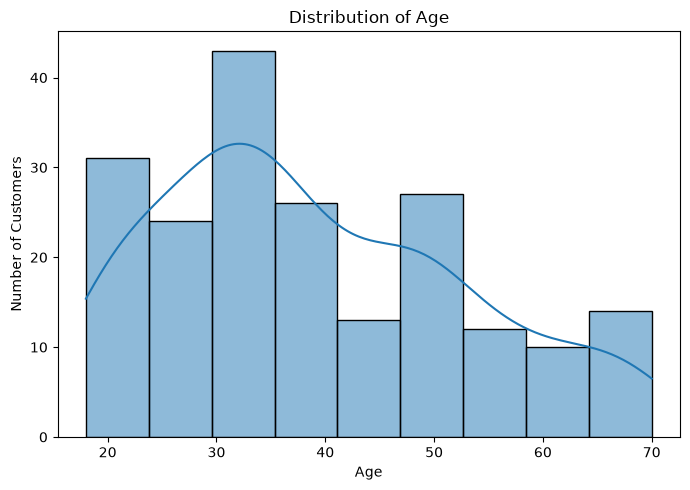

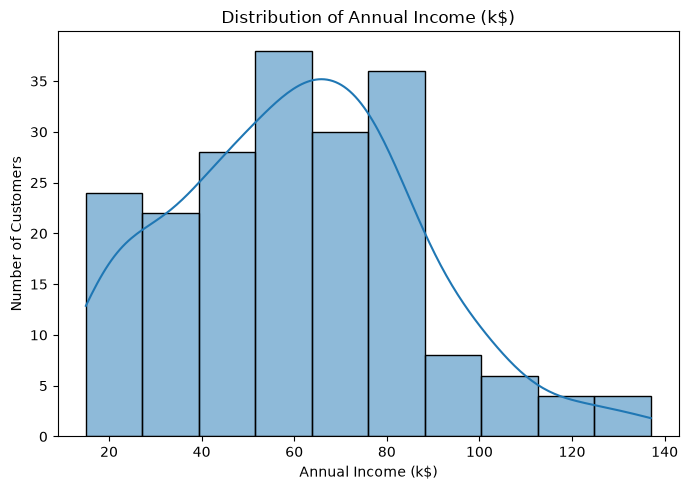

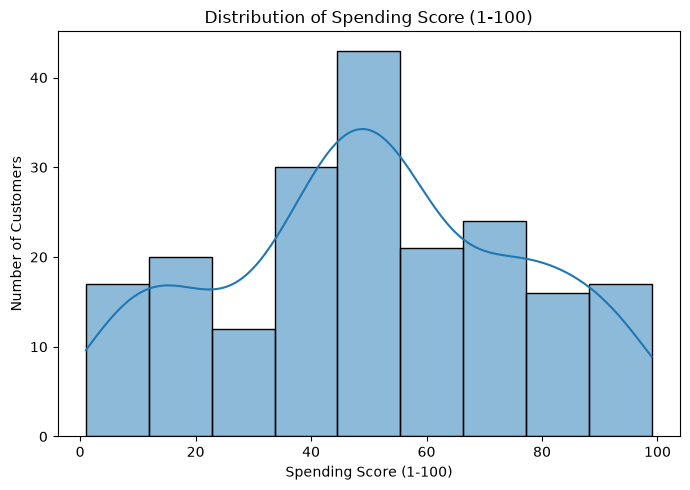

In [31]:
numeric_columns = [
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]

for column in numeric_columns:
    plt.figure(figsize=(7,5))

    sns.histplot(
        data=df,
        x=column,
        kde=True
    )

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Number of Customers")
    plt.tight_layout()
    plt.show()

### Observation
- Age Distribution => The distribution is slightly right-skewed, with most customers aged 30–35. The mean age is around 39, with a standard deviation of 14, while 75% of customers are below 49 years old.
- Annual Income => The mean annual income is approximately $60k, with a standard deviation of $26k. Around 75% of customers have an annual income below $78k, showing a relatively wide income range.
- Spending Score => The mean spending score is approximately 50, with a standard deviation of 26. The distribution is fairly symmetric, with customers spread across a wide range of spending scores.

## 2.3 Categorical features distribution

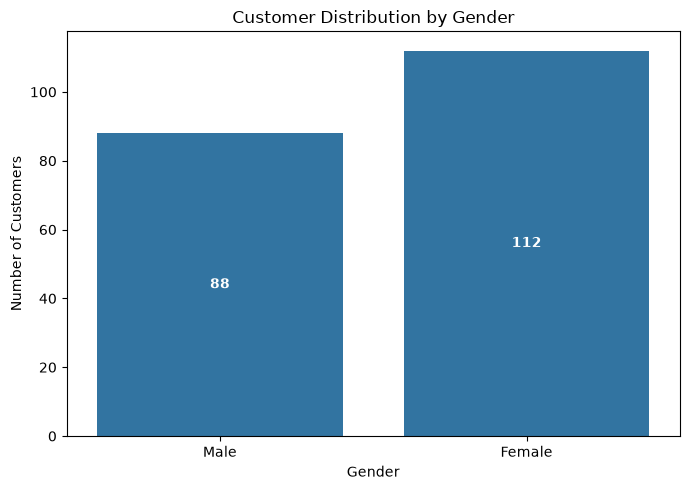

In [32]:
plt.figure(figsize=(7,5))

ax = sns.countplot(
    data=df,
    x="Gender",
)

ax.bar_label(
    ax.containers[0],
    label_type="center",
    color="white",
    fontweight="bold"
)

plt.title("Customer Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.tight_layout()

plt.show()

## 2.4 Outlier analysis

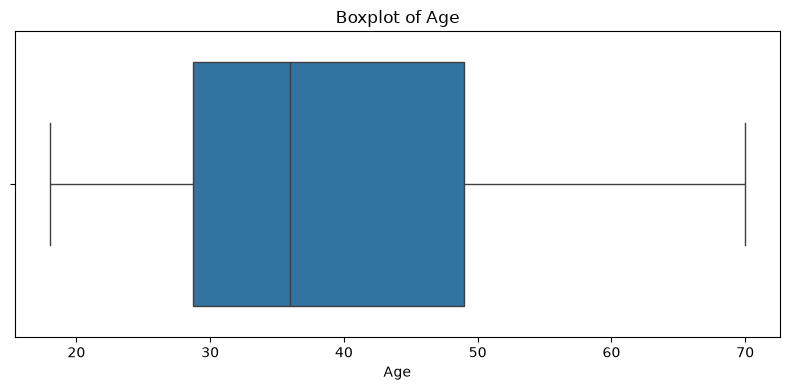

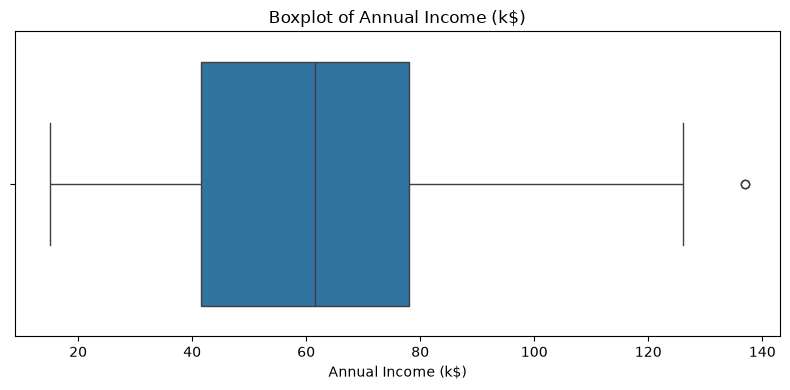

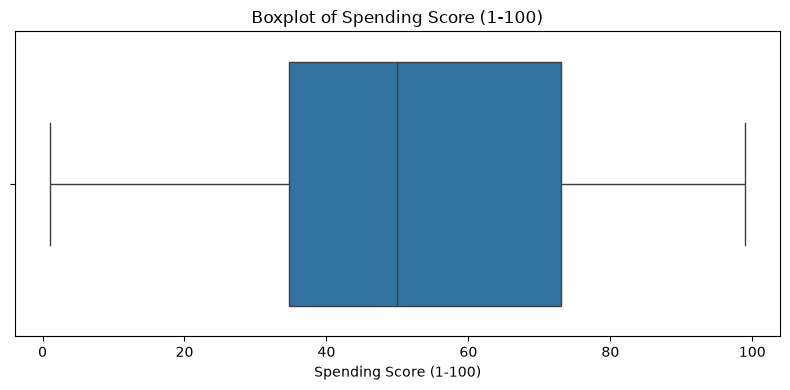

In [33]:
for column in numeric_columns:
    plt.figure(figsize=(8, 4))
    
    sns.boxplot(
        x=df[column]
    )
    
    plt.title(f"Boxplot of {column}")
    plt.xlabel(column)
    plt.tight_layout()
    plt.show()

### Observation
- Age => The boxplot shows a relatively wide age range, with no significant outliers.
- Annual Income => Customers have a relatively wide range of annual incomes, with some higher-income customers but no extreme outliers.
- Spending Score → The spending score is relatively well distributed, with no significant outliers.

## 2.5 Correlation Analysis

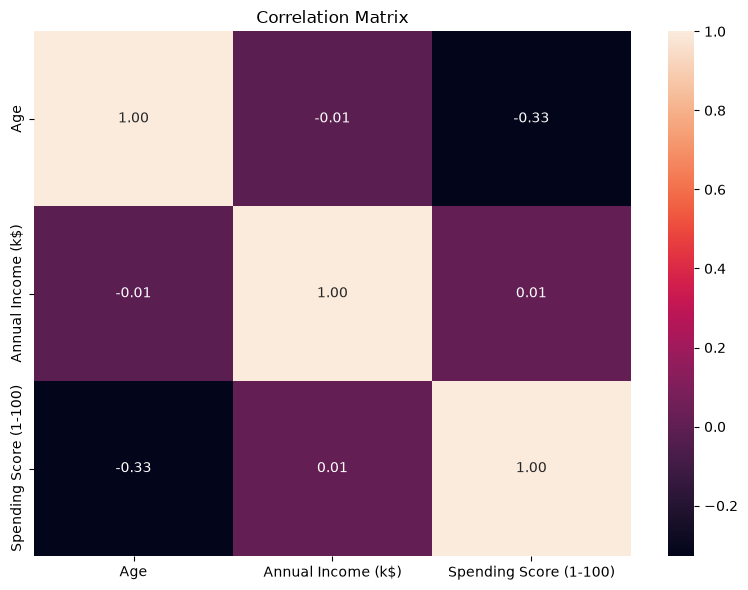

In [34]:
correlation_matrix = df[numeric_columns].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

### Observation
- Age & Spending Score => Moderate negative correlation (-0.33), suggesting that older customers tend to have slightly lower spending scores.
- Age & Annual Income => Almost no correlation (-0.01), indicating no meaningful linear relationship between age and income.
- Annual Income & Spending Score => Almost no correlation (0.01), suggesting that income alone does not determine customers' spending behavior.

# 3. Feature selection and feature scalling

In [35]:
# Selected features for clustering

features = df[[
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]]

print("SELECTED FEATURES")
print("=" * 50)

print(f"Number of features: {features.shape[1]}")
print(f"Number of observations: {features.shape[0]}")

print("\nSelected columns:")
for column in features.columns:
    print(f"• {column}")

SELECTED FEATURES
Number of features: 3
Number of observations: 200

Selected columns:
• Age
• Annual Income (k$)
• Spending Score (1-100)


### Info
`Age`, `Annual Income (k$)`, and `Spending Score (1-100)` were selected as the main features for customer segmentation. 
`CustomerID` was excluded because it is only an identifier, while `Gender` was retained for later cluster interpretation rather than used directly in K-Means.

In [36]:
scaler = StandardScaler()

features_scaled = scaler.fit_transform(features)

features_scaled = pd.DataFrame(
    features_scaled,
    columns=features.columns,
    index=features.index
)

print("SCALED FEATURES")
print("=" * 50)

display(features_scaled.describe().round(2))

SCALED FEATURES


,Age,Annual Income (k$),Spending Score (1-100)
count,200.00,200.00,200.00
mean,-0.00,-0.00,-0.00
std,1.00,1.00,1.00
min,-1.50,-1.74,-1.91
25%,-0.72,-0.73,-0.60
50%,-0.20,0.04,-0.01
75%,0.73,0.67,0.89
max,2.24,2.92,1.89


# 4. Finding the Best Number of Clusters Using Elbow Method and Silhouette Score
- **Elbow Method** → Uses the inertia score, which measures how close data points are to the centroid of their cluster. Lower inertia means more compact clusters. As the number of clusters (`K`) increases, inertia decreases. We look for the **"elbow"**, where adding another cluster no longer significantly improves the result.
- **Silhouette Score** → Measures how well each data point fits within its cluster compared to other clusters. The score ranges from **-1 to 1**:
  - Closer to **1** → well-separated clusters
  - Around **0** → overlapping clusters
  - Below **0** → points may be assigned to the wrong cluster
  
  In general, a **higher Silhouette Score** indicates better-defined clusters.

In [37]:
inertia = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(features_scaled)
    inertia.append(kmeans.inertia_)

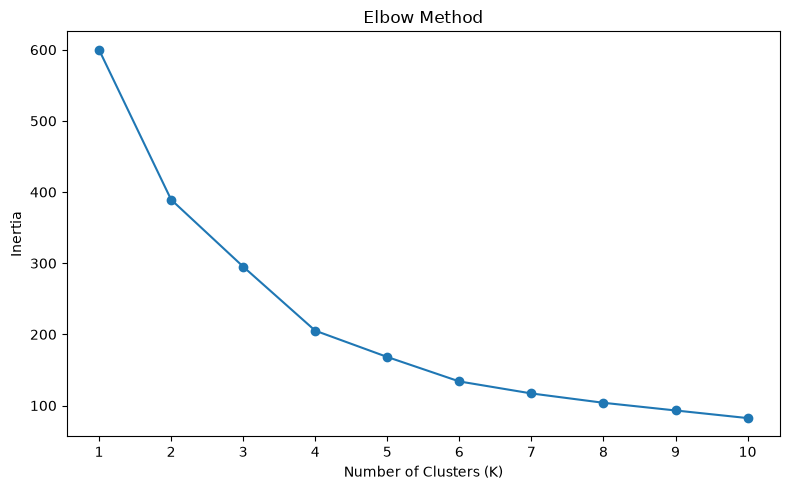

In [38]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, 11),
    inertia,
    marker="o"
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(range(1, 11))

plt.tight_layout()
plt.show()

### Observation
We can see that after **6 clusters**, the line starts to flatten and becomes almost straight. This indicates that adding more clusters provides only a small improvement, so **K = 6** can be identified as the elbow point.

In [39]:
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(features_scaled)
    
    score = silhouette_score(
        features_scaled,
        labels
    )
    
    silhouette_scores.append(score)

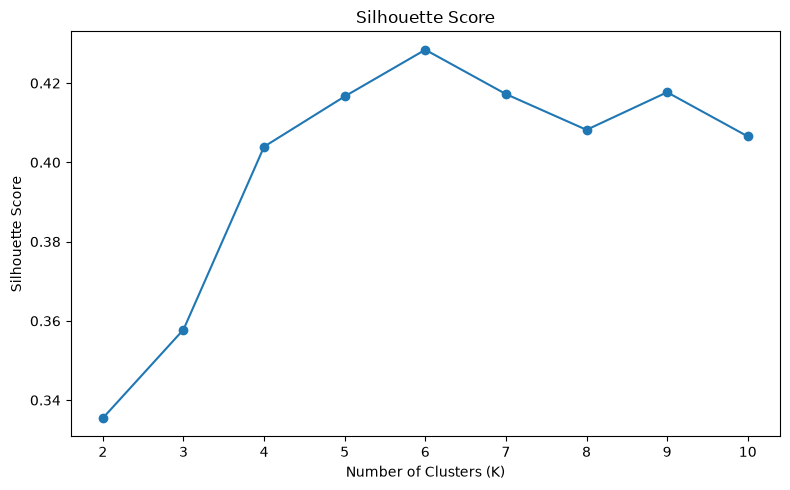

In [40]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    silhouette_scores,
    marker="o"
)

plt.title("Silhouette Score")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.xticks(range(2, 11))
plt.tight_layout()
plt.show()

### Observation
The Silhouette Score reaches its highest value at **6 clusters**, confirming the result obtained from the Elbow Method.

# 5. K-Means Clustering
**K-Means** assigns each customer to the nearest centroid based on the distance between them. After assigning all customers, the algorithm recalculates the centroid of each cluster using the mean position of its assigned customers. This process is repeated until the centroids stop changing significantly and the clusters become stable.

In [49]:
kmeans = KMeans(
    n_clusters=6,
    random_state=42,
    # Number of diffrent starting points (centroids)
    n_init=10
)

cluster_labels = kmeans.fit_predict(features_scaled)

df["Cluster"] = cluster_labels

print("CLUSTER DISTRIBUTION")
print("=" * 50)

print(df["Cluster"].value_counts().sort_index())

CLUSTER DISTRIBUTION
Cluster
0    45
1    39
2    33
3    39
4    23
5    21
Name: count, dtype: int64


# 6. Visualize the results

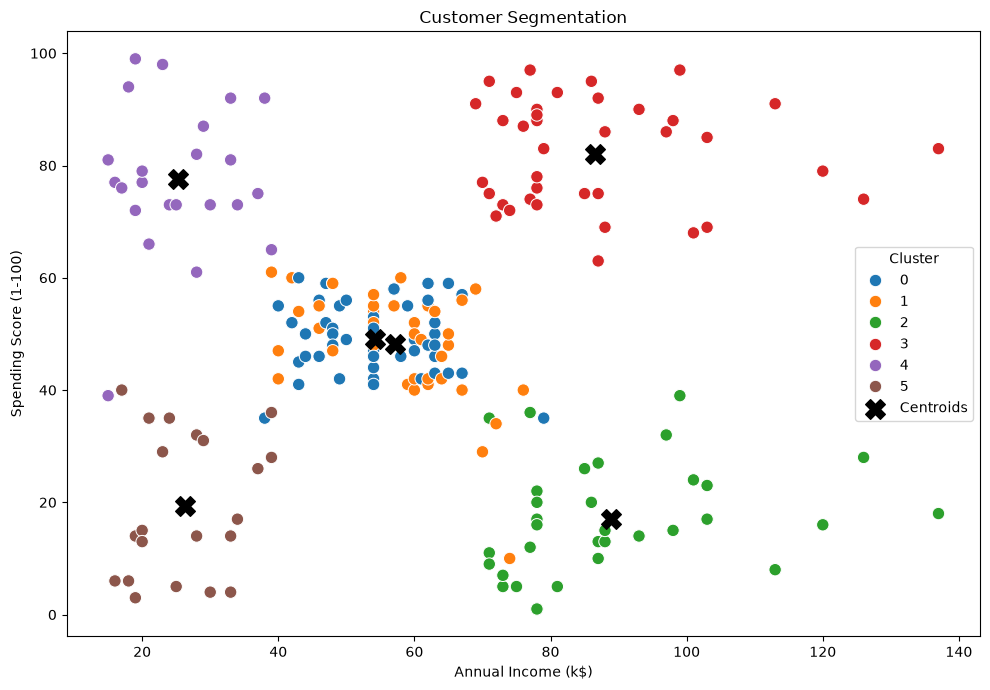

In [ ]:
centroids_original = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=features.columns
)

plt.figure(figsize=(10, 7))

# Plot customers
sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="tab10",
    s=80
)

# Plot cluster centroids
plt.scatter(
    centroids_original["Annual Income (k$)"],
    centroids_original["Spending Score (1-100)"],
    marker="X",
    s=200,
    color="black",
    label="Centroids"
)

plt.title("Customer Segmentation")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

### Observation
The K-Means algorithm divided customers into 6 clusters based on annual income and spending score. Some clusters are relatively well separated, while others, such as **Cluster 0** and **Cluster 1**, show noticeable overlap. The black X markers represent the centroids, indicating the average position of each cluster.
This suggests that some customer groups have similar income and spending patterns, making them harder to distinguish using these two features alone.

# 7. Summary

In [55]:
cluster_summary = df.groupby("Cluster").agg(
    Customers=("CustomerID", "count"),
    Avg_Age=("Age", "mean"),
    Avg_Income=("Annual Income (k$)", "mean"),
    Avg_Spending=("Spending Score (1-100)", "mean")
).round(2)

display(cluster_summary)

,Customers,Avg_Age,Avg_Income,Avg_Spending
Cluster,,,,
0,45,56.33,54.27,49.07
1,39,26.79,57.10,48.13
2,33,41.94,88.94,16.97
3,39,32.69,86.54,82.13
4,23,25.00,25.26,77.61
5,21,45.52,26.29,19.38


### Info
**Cluster 0** => Older customers with medium income and average spending.
**Cluster 1** => Young customers with medium income and average spending.
**Cluster 2** => Customers with high income but low spending.
**Cluster 3** => Customers with high income and high spending, making them a potentially really valuable customer segment.
**Cluster 4** => Young customers with low income but high spending.
**Cluster 5** => Older customers with low income and low spending.